В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням kNearestNeighboors, знайдемо оптимальні гіперпараметри для цього методу і зробимо базові ансамблі. Це дасть змогу порівняти перформанс моделі з попередніми вивченими методами.

0. Зчитайте дані `train.csv` та зробіть препроцесинг використовуючи написаний Вами скрипт `process_bank_churn.py` так, аби в результаті отримати дані в розбитті X_train, train_targets, X_val, val_targets для експериментів.

  Якщо Вам не вдалось реалізувати в завданні `2.3. Дерева прийняття рішень` скрипт `process_bank_churn.py` - можна скористатись готовим скриптом з запропонованого рішення того завдання.

In [100]:
import numpy as np
import pandas as pd
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_auc_score, RocCurveDisplay
from sklearn.tree import DecisionTreeClassifier
from process_bank_churn import preprocess_data, preprocess_new_data
# https://github.com/verabalashova/python-for-ml-tasks/blob/main/module-2/topic-2/process_bank_churn.py
from evaluation_visualizations import predict_and_plot, roc_curve_train_vs_validation
# https://github.com/verabalashova/python-for-ml-tasks/blob/main/module-2/topic-2/evaluation_visualizations.py

In [101]:
raw_df = pd.read_csv('train.csv')

processed_data_result = preprocess_data(raw_df)
#display(processed_data_result)

X_train = processed_data_result['train_X']
train_targets = processed_data_result['train_y']
X_val = processed_data_result['val_X']
val_targets = processed_data_result['val_y']

In [102]:
X_train.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
14943,0.556075,-0.453946,-1.086837,1.521378,-1.110721,0.517651,-0.982377,1.132308,1.0,0.0,0.0,0.0,1.0
2135,0.638970,-0.453946,-1.806103,0.647924,-1.110721,0.517651,1.017939,0.487011,1.0,0.0,0.0,0.0,1.0
11829,1.371209,-1.430077,1.790226,-0.716981,0.767612,0.517651,-0.982377,-0.145669,1.0,0.0,0.0,1.0,0.0
8755,-0.341954,-1.186044,0.351694,1.456011,-1.110721,0.517651,-0.982377,1.537702,0.0,1.0,0.0,1.0,0.0
8643,1.039629,-0.942011,1.070960,-0.716981,0.767612,0.517651,-0.982377,0.275892,0.0,0.0,1.0,0.0,1.0


1. Навчіть на цих даних класифікатор kNN з параметрами за замовченням і виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах. Зробіть заключення про отриману модель: вона хороша/погана, чи є high bias/high variance?

In [103]:
knn = KNeighborsClassifier()

knn.fit(X_train, train_targets)

KNeighborsClassifier()

Confusion Matrix ({name}):
 [[0.96298707 0.03701293]
 [0.29413906 0.70586094]]
F1 score: 76.28%
AUROC Score (Training Data): 0.9622


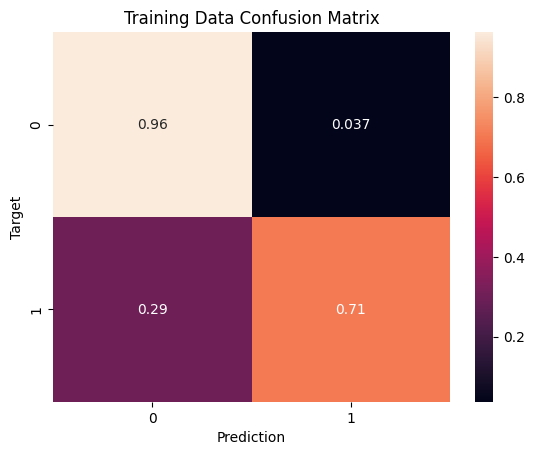

In [104]:
(train_probs, train_preds) = predict_and_plot(knn, X_train, train_targets, 'Training Data')

Confusion Matrix ({name}):
 [[0.93305439 0.06694561]
 [0.39344262 0.60655738]]
F1 score: 64.91%
AUROC Score (Validation Data): 0.8494


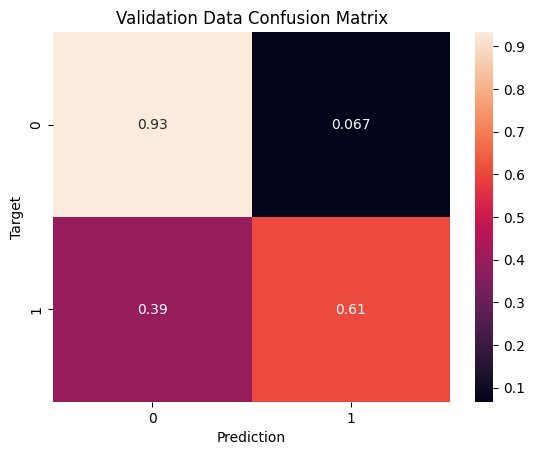

In [105]:
(val_probs, val_preds) = predict_and_plot(knn, X_val, val_targets, 'Validation Data')

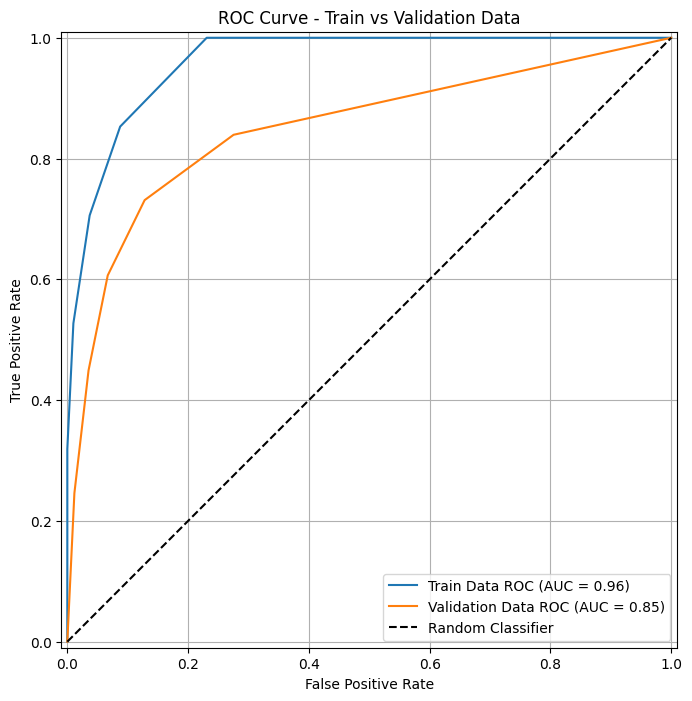

In [106]:
roc_curve_train_vs_validation(knn, X_train, train_targets, X_val, val_targets)

### Спостереження

Модель kNN зі стандартними параметрами демонструє дуже високий показник AUROC на тренувальних даних (0.9622), що свідчить про те, що вона добре "запам'ятовує" тренувальний набір. Проте, AUROC на валідаційних даних значно нижчий, це вказує, що скоріше за все є **перенавчання**. Модель гірше  узагальнює на нові, невідомі дані, незважаючи на високу точність на тренувальному наборі.

2. Використовуючи `GridSearchCV` знайдіть оптимальне значення параметра `n_neighbors` для класифікатора `kNN`. Псотавте крос валідацію на 5 фолдів.

  Після успішного завершення пошуку оптимального гіперпараметра
    - виведіть найкраще значення параметра
    - збережіть в окрему змінну `knn_best` найкращу модель, знайдену з `GridSearchCV`
    - оцініть якість передбачень  `knn_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пукнтом (2) цього завдання? Чи є вона краще за дерево прийняття рішень з попереднього ДЗ?

In [107]:
knn = KNeighborsClassifier()
params_knn = {'n_neighbors': np.arange(1, 25)}

In [108]:
%%time
knn_gs = GridSearchCV(knn, params_knn, cv=5)
knn_gs.fit(X_train, train_targets)

CPU times: user 42.9 s, sys: 44.3 ms, total: 42.9 s
Wall time: 43.3 s


GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24])})

In [109]:
knn_best = knn_gs.best_estimator_

print(knn_gs.best_params_, knn_gs.best_score_)

{'n_neighbors': np.int64(15)} 0.8857037037037037


Confusion Matrix ({name}):
 [[0.96512601 0.03487399]
 [0.36294139 0.63705861]]
F1 score: 71.84%
AUROC Score (Training Data): 0.9440


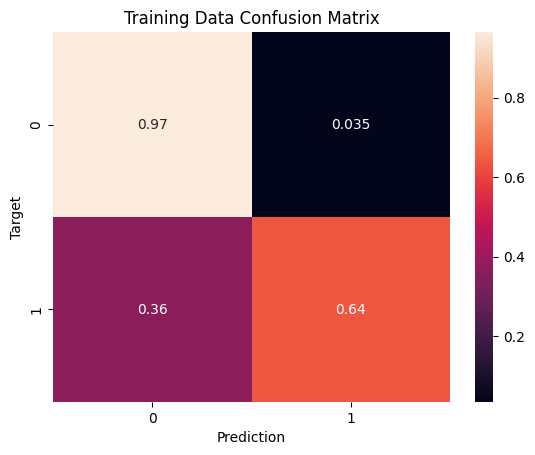

In [110]:
(train_probs, train_preds) = predict_and_plot(knn_best, X_train, train_targets, 'Training Data')

Confusion Matrix ({name}):
 [[0.94225941 0.05774059]
 [0.41311475 0.58688525]]
F1 score: 64.74%
AUROC Score (Validation Data): 0.8899


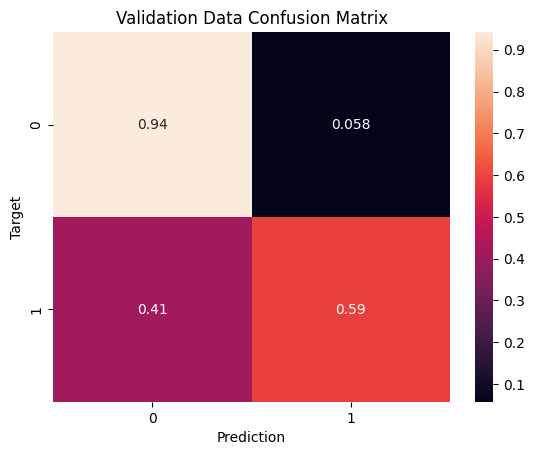

In [111]:
(val_probs, val_preds) = predict_and_plot(knn_best, X_val, val_targets, 'Validation Data')

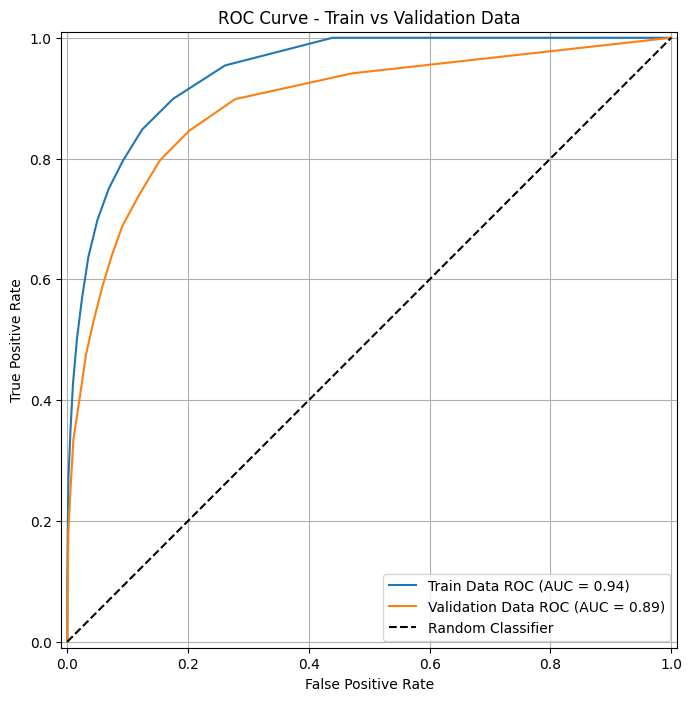

In [112]:
roc_curve_train_vs_validation(knn_best, X_train, train_targets, X_val, val_targets)

### Спостереження

Модель покращилась на валідаційних даних порівняно з попередньою моделлю з параметрами за замовчуванням. Але вона все одно не дотягує до моделі з завдання 2.3. Дерева прийняття рішень, де AUROC на валідаційних даних був 0.91 (see [here](https://github.com/verabalashova/python-for-ml-tasks/blob/main/module-2/topic-2/HW_2_3_%D0%94%D0%B5%D1%80%D0%B5%D0%B2%D0%B0_%D0%BF%D1%80%D0%B8%D0%B9%D0%BD%D1%8F%D1%82%D1%82%D1%8F_%D1%80%D1%96%D1%88%D0%B5%D0%BD%D1%8C.ipynb)).  

3. Виконайте пошук оптимальних гіперпараметрів для `DecisionTreeClassifier` з `GridSearchCV` за сіткою параметрів
  - `max_depth` від 1 до 20 з кроком 2
  - `max_leaf_nodes` від 2 до 10 з кроком 1

  Обовʼязково при цьому ініціюйте модель з фіксацією `random_state`.

  Поставте кросвалідацію на 3 фолди, `scoring='roc_auc'`, та виміряйте, скільки часу потребує пошук оптимальних гіперпараметрів.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення параметра
    - збережіть в окрему змінну `dt_best` найкращу модель, знайдену з `GridSearchCV`
    - оцініть якість передбачень  `dt_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи ця модель краща за ту, що ви знайшли вручну?

In [113]:
dt_model = DecisionTreeClassifier(random_state=42)

params_dt = {'max_depth': np.arange(1, 20, 2), 'max_leaf_nodes': np.arange(2, 10)}

In [114]:
%%time
dt_gs = GridSearchCV(dt_model, params_dt, cv=3, scoring='roc_auc')
dt_gs.fit(X_train, train_targets)

CPU times: user 6.31 s, sys: 10.9 ms, total: 6.33 s
Wall time: 6.43 s


GridSearchCV(cv=3, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'max_depth': array([ 1,  3,  5,  7,  9, 11, 13, 15, 17, 19]),
                         'max_leaf_nodes': array([2, 3, 4, 5, 6, 7, 8, 9])},
             scoring='roc_auc')

In [115]:
dt_best = dt_gs.best_estimator_

print(dt_gs.best_params_, dt_gs.best_score_)

{'max_depth': np.int64(5), 'max_leaf_nodes': np.int64(9)} 0.9002465749446977


Confusion Matrix ({name}):
 [[0.96494002 0.03505998]
 [0.44739716 0.55260284]]
F1 score: 65.40%
AUROC Score (Training Data): 0.9007


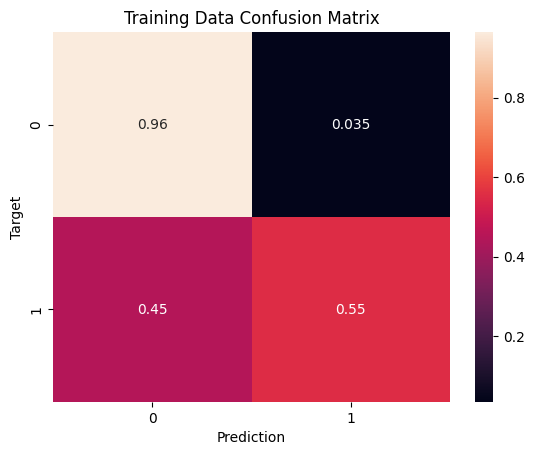

In [116]:
(train_probs, train_preds) = predict_and_plot(dt_best, X_train, train_targets, 'Training Data')

Confusion Matrix ({name}):
 [[0.96401674 0.03598326]
 [0.48852459 0.51147541]]
F1 score: 61.90%
AUROC Score (Validation Data): 0.8916


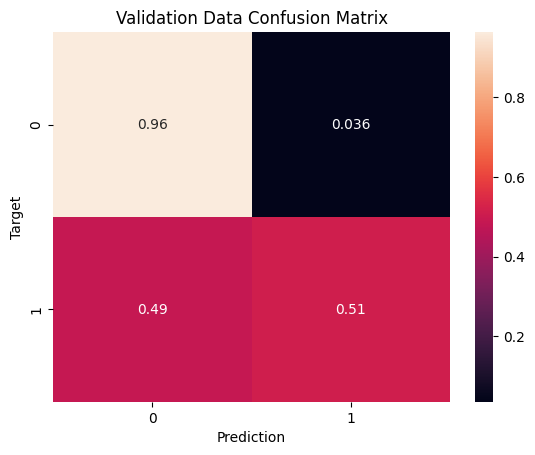

In [117]:
(val_probs, val_preds) = predict_and_plot(dt_best, X_val, val_targets, 'Validation Data')

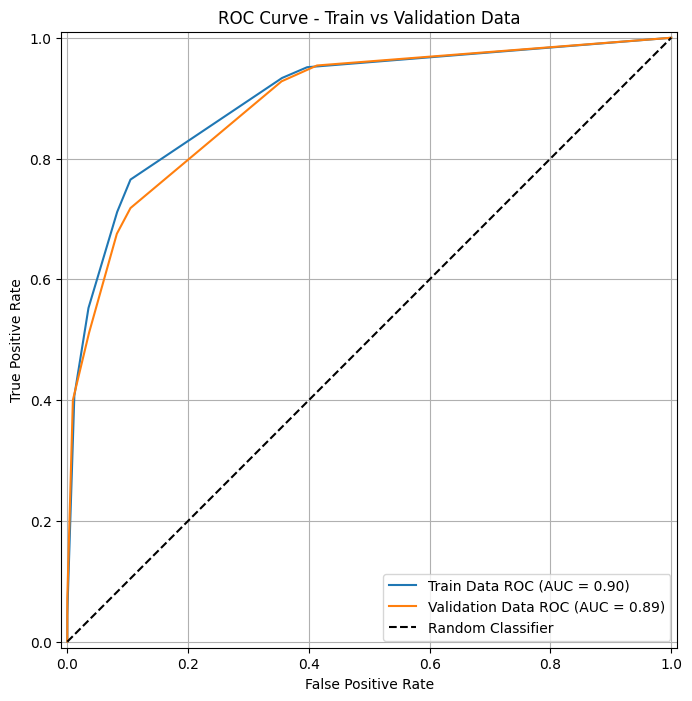

In [118]:
roc_curve_train_vs_validation(dt_best, X_train, train_targets, X_val, val_targets)

### Спостереження

Дана модель непогана, як і з knn_best показує 0.89 для валідаційної вибірки (тобто так само непогано моделює на даних, яких не бачила), але в *2.3 Дерева прийняття рішень* було знайдено модель з трошки кращими AUROC (0.93 для тренувальної і 0.91 для валідаційної вибірки).

4. Виконайте пошук оптимальних гіперпараметрів для `DecisionTreeClassifier` з `RandomizedSearchCV` за заданою сіткою параметрів і кількість ітерацій 40.

  Поставте кросвалідацію на 3 фолди, `scoring='roc_auc'`, зафіксуйте `random_seed` процедури крос валідації та виміряйте, скільки часу потребує пошук оптимальних гіперпараметрів.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення параметра
    - збережіть в окрему змінну `dt_random_search_best` найкращу модель, знайдену з `RandomizedSearchCV`
    - оцініть якість передбачень  `dt_random_search_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи ця модель краща за ту, що ви знайшли з `GridSearch`?
    - проаналізуйте параметри `dt_random_search_best` і порівняйте з параметрами `dt_best` - яку бачите відмінність? Ця вправа потрібна аби зрозуміти, як різні налаштування `DecisionTreeClassifier` впливають на якість моделі.

In [119]:
dt_model = DecisionTreeClassifier(random_state=42)

params_dt = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': np.arange(1, 20),
    'max_leaf_nodes': np.arange(2, 20),
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': [None, 'sqrt', 'log2']
}

In [120]:
%%time

dt_rs = RandomizedSearchCV(
    dt_model,
    params_dt,
    n_iter = 40,
    cv=3,
    scoring="roc_auc",
    random_state = 42,
    refit=True
)

dt_rs.fit(X_train, train_targets)

CPU times: user 1.8 s, sys: 6.02 ms, total: 1.8 s
Wall time: 1.81 s


RandomizedSearchCV(cv=3, estimator=DecisionTreeClassifier(random_state=42),
                   n_iter=40,
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19]),
                                        'max_features': [None, 'sqrt', 'log2'],
                                        'max_leaf_nodes': array([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
       19]),
                                        'min_samples_leaf': [1, 2, 4, 8],
                                        'min_samples_split': [2, 5, 10, 20],
                                        'splitter': ['best', 'random']},
                   random_state=42, scoring='roc_auc')

In [121]:
dt_random_search_best  = dt_rs.best_estimator_

print(dt_rs.best_params_, dt_rs.best_score_)

{'splitter': 'best', 'min_samples_split': 20, 'min_samples_leaf': 2, 'max_leaf_nodes': np.int64(14), 'max_features': None, 'max_depth': np.int64(16), 'criterion': 'entropy'} 0.9129597232385155


Confusion Matrix ({name}):
 [[0.94550358 0.05449642]
 [0.34655988 0.65344012]]
F1 score: 70.01%
AUROC Score (Training Data): 0.9152


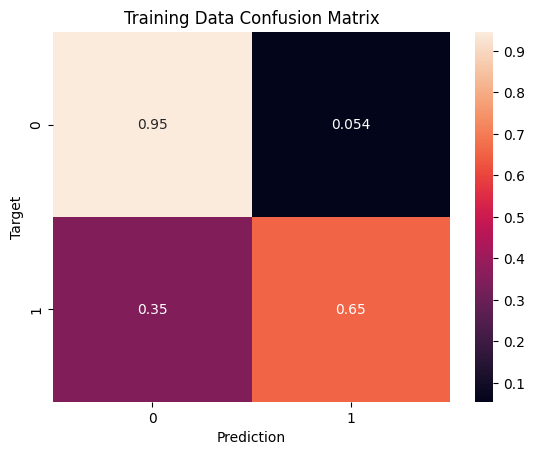

In [122]:
(train_probs, train_preds) = predict_and_plot(dt_random_search_best, X_train, train_targets, 'Training Data')

Confusion Matrix ({name}):
 [[0.94979079 0.05020921]
 [0.36065574 0.63934426]]
F1 score: 69.64%
AUROC Score (Validation Data): 0.9069


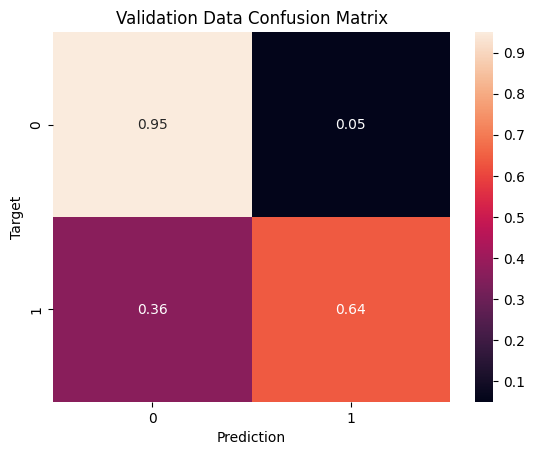

In [123]:
(val_probs, val_preds) = predict_and_plot(dt_random_search_best, X_val, val_targets, 'Validation Data')

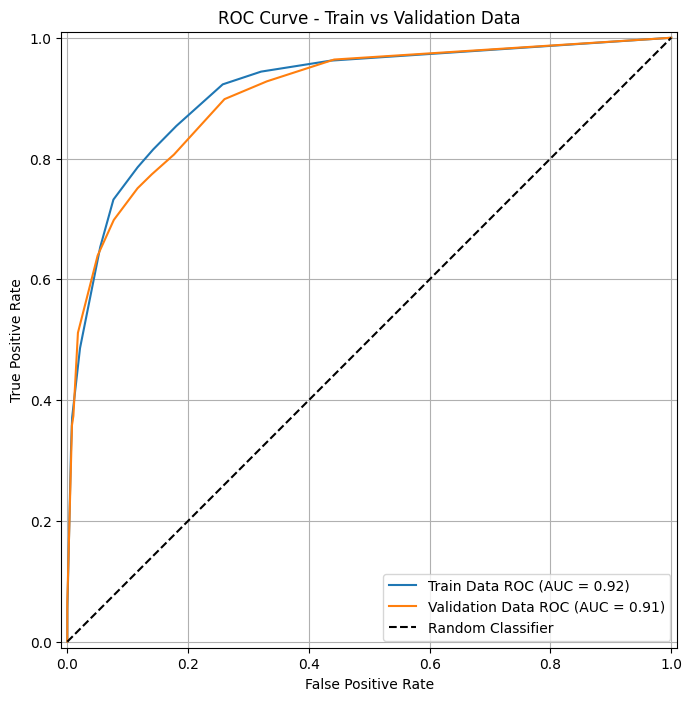

In [124]:
roc_curve_train_vs_validation(dt_random_search_best, X_train, train_targets, X_val, val_targets)

### Спостереження

1.  **Оцінка якості передбачень `dt_random_search_best`:**
    *   **AUROC на тренувальній вибірці:** 0.9152
    *   **AUROC на валідаційній вибірці:** 0.9069

    Модель `dt_random_search_best` показує класні результати AUROC як на тренувальній, так і на валідаційній вибірці. Значення близькі одне до одного, що свідчить про добру узагальнюючу здатність моделі та відсутність перенавчання (хоча тренувальний AUROC трохи вищий, що є логічним, бо модель бачила вже ті дані).

2.  **Порівняння з моделлю, знайденою за допомогою `GridSearchCV` (`dt_best`):**
    *   **`dt_best` (GridSearchCV):**
        *   AUROC на тренувальній вибірці: 0.9007
        *   AUROC на валідаційній вибірці: 0.8916

    Модель `dt_random_search_best` (`RandomizedSearchCV`) краща за модель `dt_best` (`GridSearchCV`) за показниками AUROC на обох вибірках. AUROC на валідаційній вибірці для `dt_random_search_best` (0.9069) вищий, ніж для `dt_best` (0.8916). Це свідчить про те, що `RandomizedSearchCV` зміг знайти кращий набір гіперпараметрів, що призвело до більш ефективної моделі.

3.  **Аналіз параметрів `dt_random_search_best` та порівняння з `dt_best`:**
    *   **Параметри `dt_random_search_best`:**
        `{'splitter': 'best', 'min_samples_split': 20, 'min_samples_leaf': 2, 'max_leaf_nodes': 14, 'max_features': None, 'max_depth': 16, 'criterion': 'entropy'}`
    *   **Параметри `dt_best`:**
        `{'max_depth': 5, 'max_leaf_nodes': 9}`

    **Відмінності:**
    *   **`max_depth`:** `dt_random_search_best` має значно більшу максимальну глибину дерева (16 проти 5). Припущення: це дозволяє моделі вивчати складніші взаємозв'язки в даних.
    *   **`max_leaf_nodes`:** `dt_random_search_best` також має більше максимальних листових вузлів (14 проти 9). Це корелює з більшою глибиною і дозволяє дереву бути більш розгалуженим.
    *   **Додаткові параметри:** `dt_random_search_best` загалом використовує набагато ширший набір оптимізованих параметрів, ніж `dt_best`. `RandomizedSearchCV` шукав оптимальні значення для `criterion` (entropy), `splitter` (best), `min_samples_split` (20), `min_samples_leaf` (2), та `max_features` (None), які не були частиною сітки `GridSearchCV` для `dt_best`. Ці додаткові параметри дають `RandomizedSearchCV` більше гнучкості для пошуку кращих комбінацій.
    *   **Критерій поділу (`criterion`):** `dt_random_search_best` обрав 'entropy', тоді як `dt_best` за замовчуванням використовував 'gini'.

    **Висновок про вплив параметрів:** Ширший діапазон і різноманітність гіперпараметрів, які були досліджені `RandomizedSearchCV` (включно з `criterion`, `splitter`, `min_samples_split`, `min_samples_leaf`, `max_features`), дозволили знайти більш оптимальну конфігурацію моделі, яка краще узагальнює на невидимих даних. Зокрема, збільшення `max_depth` та `max_leaf_nodes` у поєднанні з іншими регуляризуючими параметрами (`min_samples_split`, `min_samples_leaf`) допомогло моделі вивчити достатньо складну структуру даних без надмірного перенавчання.

### Спостереження


5. Якщо у Вас вийшла метрика `AUROC` в цій серії експериментів - зробіть ще один `submission` на Kaggle і додайте код для цього і скріншот скора на публічному лідерборді нижче.

  Сподіваюсь на цьому етапі ви вже відчули себе справжнім дослідником 😉

In [125]:
test_df = pd.read_csv('test.csv')
X_test = preprocess_new_data(test_df,
                                          processed_data_result['numeric_cols'],
                                          processed_data_result['categorical_cols'],
                                          processed_data_result['encoded_cols'],
                                          processed_data_result['scaler'],
                                          processed_data_result['encoder'])
#display(processed_test_data)

test_prob = dt_random_search_best.predict_proba(X_test)[:, 1]
test_df['Exited'] = test_prob

submission_df = pd.read_csv('sample_submission.csv')
display('Read from a file: ', submission_df[:5])
print()
print('------------------')
print()

submission_df['Exited'] = test_df['Exited']
display('Predictied with decition tree model: ', submission_df[:5])

submission_df.to_csv('submission_dec_tree.csv', index=False)

'Read from a file: '

,id,Exited
0,15000,0.5
1,15001,0.5
2,15002,0.5
3,15003,0.5
4,15004,0.5



------------------



'Predictied with decition tree model: '

,id,Exited
0,15000,0.254325
1,15001,0.016867
2,15002,0.205769
3,15003,0.560976
4,15004,0.078273


### Спостереження

І все ж логістична регресія показала себе найкраще (тому скор залишається як є):

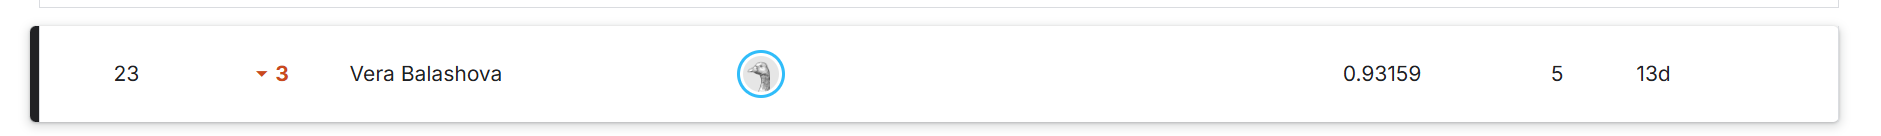